CREDIT CARD FRAUD DATA - Initial Exploration

Dataset shape: (284807, 31)

Column names and data types:
Time    float64
V1      float64
V2      float64
V3      float64
V4      float64
dtype: object

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Descriptive statistics for Amount:


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.17%


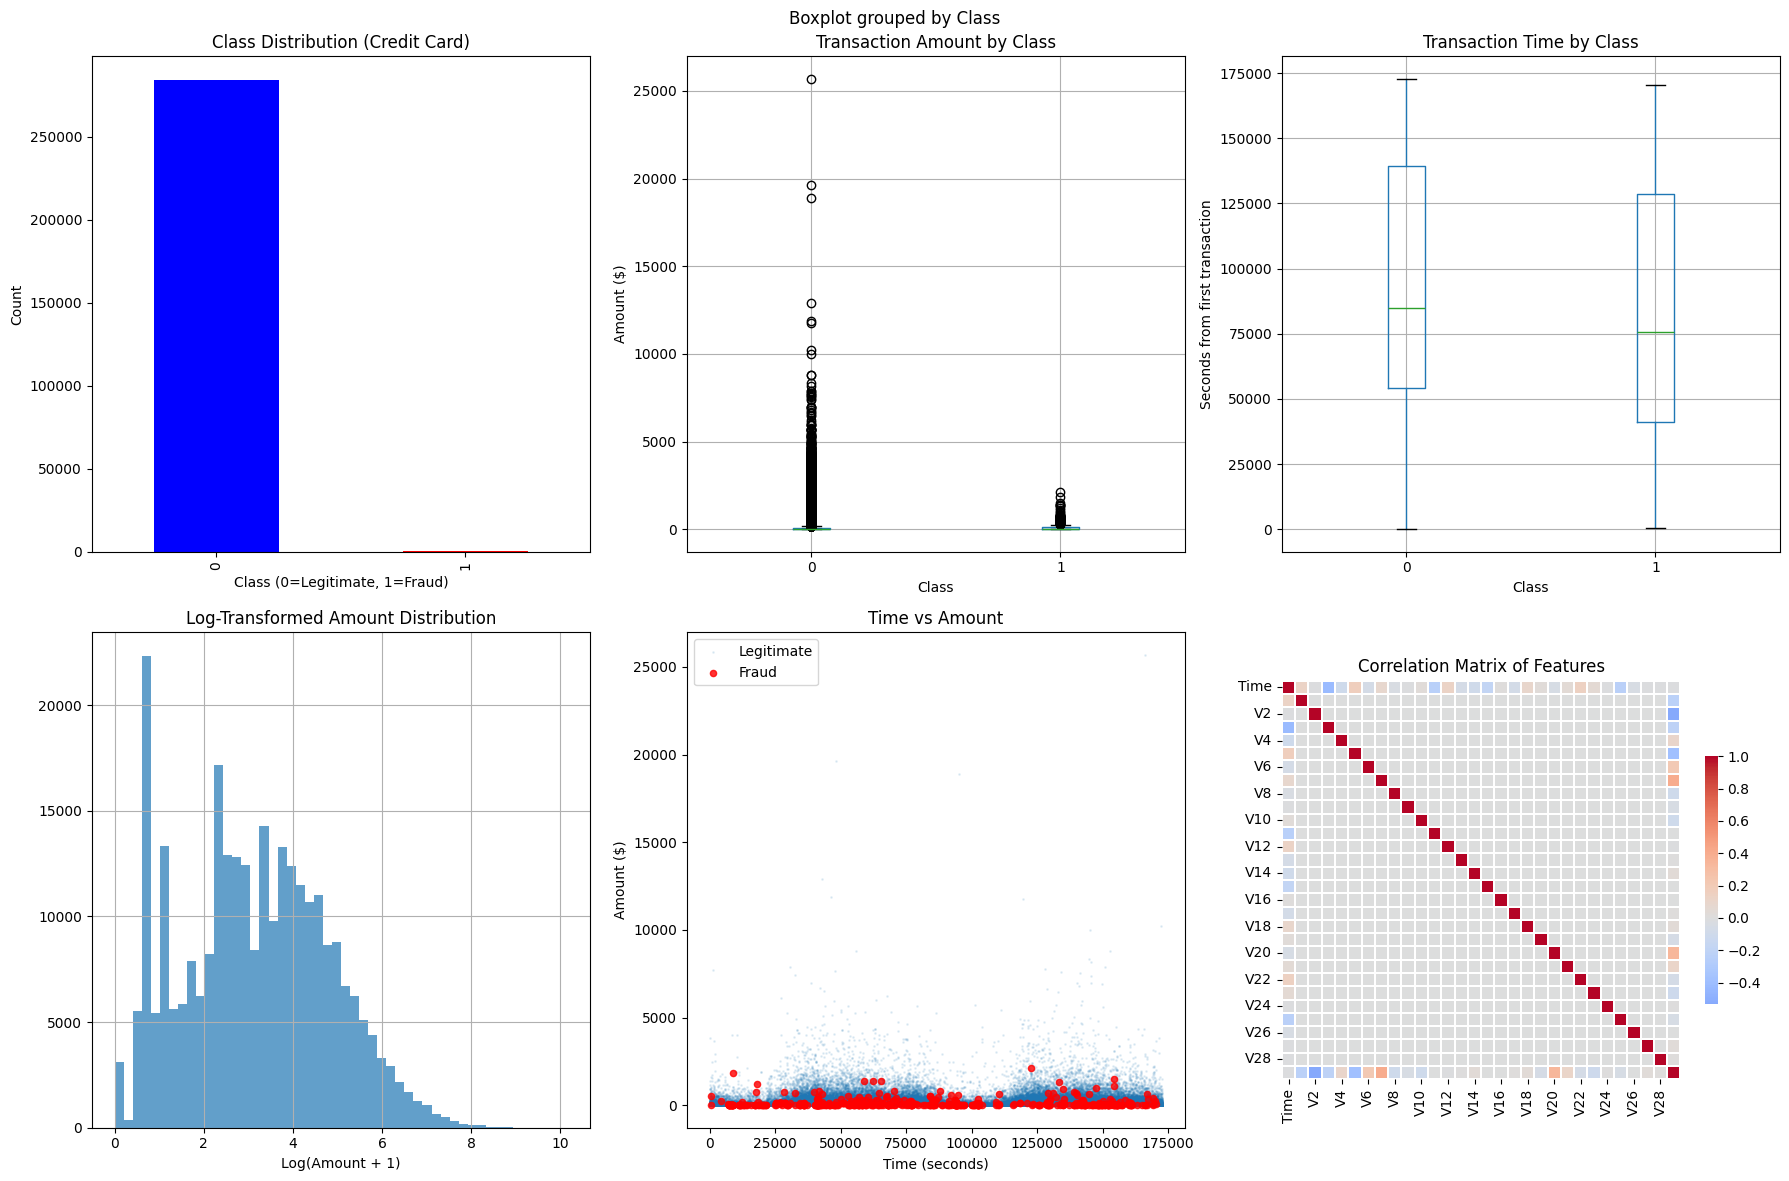


Credit Card Data Preprocessing Complete
New features added: 5
Shape: (284807, 37)

Credit card data saved to: ../data/processed/creditcard_processed.csv


In [2]:
"""
EDA for Credit Card Fraud Data
Task 1 - Data Analysis and Preprocessing
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load credit card data
credit_df = pd.read_csv('../data/raw/creditcard.csv')

print("="*60)
print("CREDIT CARD FRAUD DATA - Initial Exploration")
print("="*60)

print(f"\nDataset shape: {credit_df.shape}")
print("\nColumn names and data types:")
print(credit_df.dtypes.head())

print("\nFirst 5 rows:")
display(credit_df.head())

print("\nDescriptive statistics for Amount:")
display(credit_df['Amount'].describe())

print("\nMissing values per column:")
print(credit_df.isnull().sum())

print("\nClass distribution:")
print(credit_df['Class'].value_counts())
print(f"\nFraud percentage: {credit_df['Class'].mean()*100:.2f}%")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Class distribution
credit_df['Class'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['blue', 'red'])
axes[0, 0].set_title('Class Distribution (Credit Card)')
axes[0, 0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 0].set_ylabel('Count')

# 2. Amount distribution by class
credit_df.boxplot(column='Amount', by='Class', ax=axes[0, 1])
axes[0, 1].set_title('Transaction Amount by Class')
axes[0, 1].set_ylabel('Amount ($)')
plt.suptitle('')

# 3. Time distribution by class
credit_df.boxplot(column='Time', by='Class', ax=axes[0, 2])
axes[0, 2].set_title('Transaction Time by Class')
axes[0, 2].set_ylabel('Seconds from first transaction')

# 4. Amount histogram (log scale)
credit_df['Amount_log'] = np.log1p(credit_df['Amount'])
credit_df['Amount_log'].hist(bins=50, ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title('Log-Transformed Amount Distribution')
axes[1, 0].set_xlabel('Log(Amount + 1)')

# 5. Time vs Amount for fraud vs legitimate
fraud = credit_df[credit_df['Class'] == 1]
legit = credit_df[credit_df['Class'] == 0]
axes[1, 1].scatter(legit['Time'], legit['Amount'], alpha=0.1, label='Legitimate', s=1)
axes[1, 1].scatter(fraud['Time'], fraud['Amount'], alpha=0.8, label='Fraud', s=20, color='red')
axes[1, 1].set_title('Time vs Amount')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylabel('Amount ($)')
axes[1, 1].legend()

# 6. Correlation heatmap of PCA features
correlation_matrix = credit_df.iloc[:, :30].corr()
sns.heatmap(correlation_matrix, ax=axes[1, 2], cmap='coolwarm', center=0, 
            square=True, linewidths=0.1, cbar_kws={"shrink": 0.5})
axes[1, 2].set_title('Correlation Matrix of Features')

plt.tight_layout()
plt.savefig('../data/processed/creditcard_eda.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FEATURE ENGINEERING FOR CREDIT CARD DATA
# ============================================================================

def preprocess_credit_data(df):
    """Preprocess credit card data"""
    df_proc = df.copy()
    
    # 1. Scale Amount (since it's not PCA-transformed)
    scaler = StandardScaler()
    df_proc['Amount_scaled'] = scaler.fit_transform(df_proc[['Amount']])
    
    # 2. Create time-based features
    # Convert time to hours
    df_proc['Time_hours'] = df_proc['Time'] / 3600
    
    # 3. Time bins (for pattern analysis)
    df_proc['Time_bin'] = pd.cut(df_proc['Time_hours'], 
                                 bins=24, 
                                 labels=range(24))
    
    # 4. Amount bins
    df_proc['Amount_bin'] = pd.cut(df_proc['Amount'], 
                                   bins=[0, 50, 100, 500, 1000, 5000, float('inf')],
                                   labels=['0-50', '50-100', '100-500', '500-1000', '1000-5000', '5000+'])
    
    # 5. Interaction features (optional - can be expanded)
    # For example, average amount per time period
    df_proc['avg_amount_by_time'] = df_proc.groupby('Time_bin')['Amount'].transform('mean')
    
    return df_proc

credit_processed = preprocess_credit_data(credit_df)

print("\nCredit Card Data Preprocessing Complete")
print(f"New features added: {len(credit_processed.columns) - len(credit_df.columns)}")
print(f"Shape: {credit_processed.shape}")

# Save processed data
credit_processed.to_csv('../data/processed/creditcard_processed.csv', index=False)

print("\nCredit card data saved to: ../data/processed/creditcard_processed.csv")